# Amazon Diwali Product Sales 2025

## Business Objective
Analyze Amazon Diwali 2025 sales data to:
1. Identify top-performing product categories
2. Understand pricing and quantity impact on revenue
3. Analyze payment behavior
4. Provide data-driven recommendations to improve sales strategy


# Dataset Column Descriptions

#### Order_ID   --   A unique identifier assigned to each order placed on the platform.

#### Date   --   Represents the date on which the order was placed.

#### Customer_ID   --   A unique identifier associated with each customer.

#### Product_Category   --   Indicates the category to which the purchased product belongs.

#### Product_Name   --   Specifies the name of the product purchased by the customer.

#### Quantity   --   Denotes the number of units of a product purchased in a single order.

#### Unit_Price_INR   --   Represents the price of a single unit of the product, expressed in Indian Rupees (INR).

#### Total_Sales_INR   --   Indicates the total sales value generated from an order, calculated as the product of unit price and quantity.

#### Payment_Method   --   Specifies the payment mode used by the customer, such as cash, credit card, debit card, or UPI.

#### Delivery_Status   --   Indicates the delivery outcome of the order, such as delivered, pending, or cancelled.

#### Review_Rating   --   Represents the customer’s rating for the product on a scale ranging from 1 to 5.

#### Review_Text   --   Contains the textual feedback or comments provided by the customer regarding the product.

#### State   --   Specifies the Indian state from which the order was placed.

#### Country   --   Indicates the country where the order originated.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Loading Dataset

In [2]:
df = pd.read_csv('amazon_sales_2025.csv')

In [3]:
df.head()

,Order_ID,Date,Customer_ID,Product_Category,Product_Name,Quantity,Unit_Price_INR,Total_Sales_INR,Payment_Method,Delivery_Status,Review_Rating,Review_Text,State,Country
0,ORD100000,2025-01-25,CUST2796,Home & Kitchen,Cookware Set,2.0,25574.41,51148.82,Credit Card,Returned,1.0,Waste of money,Sikkim,India
1,ORD100001,2025-08-28,CUST9669,Beauty,Hair Dryer,NaN,19361.41,19361.41,Debit Card,Returned,5.0,Excellent product!,Telangana,India
2,ORD100002,2025-02-27,CUST5808,Electronics,Tablet,3.0,38476.22,115428.66,Cash on Delivery,Delivered,3.0,NaN,Nagaland,India
3,ORD100003,2025-02-24,CUST5889,Electronics,Headphones,NaN,38145.72,190728.60,Credit Card,Delivered,5.0,Highly recommend!,Assam,India
4,ORD100004,2025-06-15,CUST9005,Clothing,Saree,5.0,NaN,229704.90,UPI,Delivered,5.0,Highly recommend!,Odisha,India


In [4]:
print(f"NO. OF Rows: {df.shape[0]}   \nNO. OF Columns: {df.shape[1]}")

NO. OF Rows: 15450   
NO. OF Columns: 14


## Checking Structure of the Dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15450 entries, 0 to 15449
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          14707 non-null  object 
 1   Date              14690 non-null  object 
 2   Customer_ID       14670 non-null  object 
 3   Product_Category  14714 non-null  object 
 4   Product_Name      14720 non-null  object 
 5   Quantity          14655 non-null  float64
 6   Unit_Price_INR    14705 non-null  float64
 7   Total_Sales_INR   14709 non-null  float64
 8   Payment_Method    14656 non-null  object 
 9   Delivery_Status   14707 non-null  object 
 10  Review_Rating     14660 non-null  float64
 11  Review_Text       14656 non-null  object 
 12  State             14721 non-null  object 
 13  Country           14684 non-null  object 
dtypes: float64(4), object(10)
memory usage: 1.7+ MB


In [6]:
df.describe()

,Quantity,Unit_Price_INR,Total_Sales_INR,Review_Rating
count,14655.000000,14705.000000,14709.000000,14660.000000
mean,2.990038,24976.084954,74694.470355,3.042974
std,1.425473,14424.018608,59482.200362,1.409549
min,1.000000,202.570000,204.050000,1.000000
25%,2.000000,12514.690000,27124.820000,2.000000
50%,3.000000,24921.360000,57385.800000,3.000000
75%,4.000000,37577.440000,112610.430000,4.000000
max,5.000000,49994.430000,249955.500000,5.000000


In [7]:
df.describe(include='O')

,Order_ID,Date,Customer_ID,Product_Category,Product_Name,Payment_Method,Delivery_Status,Review_Text,State,Country
count,14707,14690,14670,14714,14720,14656,14707,14656,14721,14684
unique,14272,365,7132,5,25,4,3,25,28,1
top,ORD101533,2025-05-26,CUST7512,Books,Children's Book,Cash on Delivery,Delivered,Satisfied with the product,Sikkim,India
freq,2,59,9,2986,627,3736,4983,644,589,14684


In [8]:
df.dtypes

Order_ID             object
Date                 object
Customer_ID          object
Product_Category     object
Product_Name         object
Quantity            float64
Unit_Price_INR      float64
Total_Sales_INR     float64
Payment_Method       object
Delivery_Status      object
Review_Rating       float64
Review_Text          object
State                object
Country              object
dtype: object

In [9]:
df.columns

Index(['Order_ID', 'Date', 'Customer_ID', 'Product_Category', 'Product_Name',
       'Quantity', 'Unit_Price_INR', 'Total_Sales_INR', 'Payment_Method',
       'Delivery_Status', 'Review_Rating', 'Review_Text', 'State', 'Country'],
      dtype='object')

## Checking Missing Values

In [22]:
df.isnull().sum()

Order_ID            743
Date                760
Customer_ID         780
Product_Category    736
Product_Name        730
Quantity            795
Unit_Price_INR      745
Total_Sales_INR     741
Payment_Method      794
Delivery_Status     743
Review_Rating       790
Review_Text         794
State               729
Country             766
dtype: int64

## Number of Duplicate Rows

In [11]:
df.duplicated().sum()

np.int64(450)

## Removing Duplicated Rows

In [12]:
df = df.drop_duplicates()

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.shape

(15000, 14)

### Filling missing Values And Removing Unwanted Data

#### Columns : ['Order_ID','Date','Customer_ID']

In [15]:
df.dropna(subset=['Order_ID','Date','Customer_ID'], inplace=True)

#### Columns : ['Product_Category','Product_Name']

In [16]:
df['Product_Category'].fillna('Unkown',inplace=True)
df['Product_Name'].fillna('Unkown',inplace=True)

#### Column : ['Quantity']

In [17]:
df['Quantity'].fillna(df['Quantity'].median(), inplace=True)

#### Column : ['Unit_Price_INR']

In [18]:
df['Unit_Price_INR'] = df.groupby(['Product_Category'])['Unit_Price_INR'].transform(lambda x : x.fillna(x.median()))

#### Column : ['Total_Sales_INR']

In [19]:
fill = df['Unit_Price_INR'] * df['Quantity']
df['Total_Sales_INR'].fillna(fill,inplace=True)

#### Columns : ['Payment_Method','Delivery_Status']

In [20]:
df['Payment_Method'].fillna(df['Payment_Method'].mode()[0],inplace=True)
df['Delivery_Status'].fillna(df['Delivery_Status'].mode()[0],inplace=True)

#### Columns : ['Review_Rating','Review_Text']

In [21]:
df['Review_Rating'].fillna(df['Review_Rating'].median(),inplace=True)
df['Review_Text'].fillna('No Review',inplace=True)

#### Columns : ['State','Country']

In [22]:
df['State'].fillna(df['State'].mode()[0],inplace=True)
df['Country'].fillna('India',inplace=True)

#### Creating new feature columns

In [23]:

df['Date'] = pd.to_datetime(df['Date'],infer_datetime_format=True)  # converts object data type into datatime datatype..

df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [24]:
df.drop('Date',axis=1,inplace=True)

In [25]:
df.rename(columns={'Day':'Order_day','Month':'Order_Month','Year':'Order_Year'},inplace=True)
df['Order_day'] = pd.to_datetime(df['Order_day'])
df['Day_of_Week'] = df['Order_day'].dt.day_name()
df['Average_Order_value'] = df['Total_Sales_INR'] / df['Quantity']

In [26]:
df.isnull().sum()

Order_ID               0
Customer_ID            0
Product_Category       0
Product_Name           0
Quantity               0
Unit_Price_INR         0
Total_Sales_INR        0
Payment_Method         0
Delivery_Status        0
Review_Rating          0
Review_Text            0
State                  0
Country                0
Order_day              0
Order_Month            0
Order_Year             0
Day_of_Week            0
Average_Order_value    0
dtype: int64

# Univariate Analysis

In [27]:
df['Payment_Method'].value_counts()

Payment_Method
Cash on Delivery    3756
Credit Card         3102
UPI                 3011
Debit Card          3009
Name: count, dtype: int64

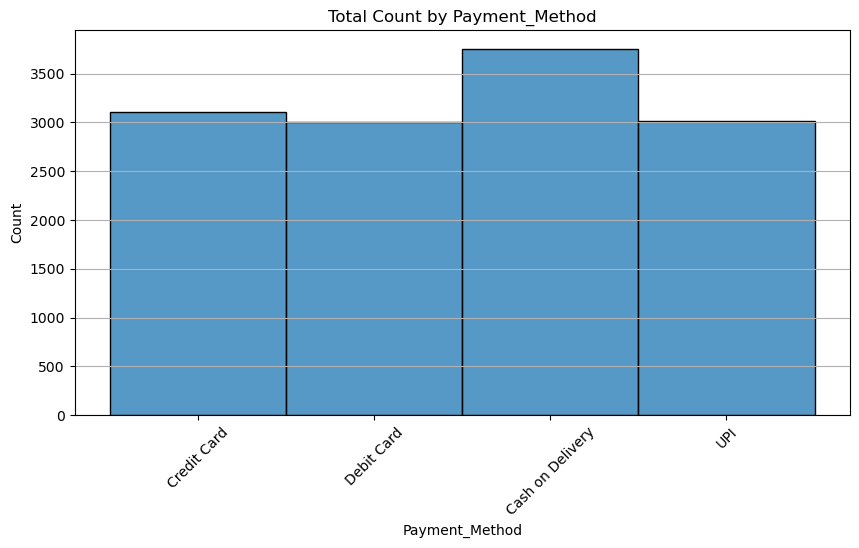

In [28]:
plt.figure(figsize=(10,5))
sns.histplot(x='Payment_Method', data=df)
plt.title('Total Count by Payment_Method')
plt.xlabel('Payment_Method')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

In [29]:
df['Quantity'].describe()

count    12878.000000
mean         2.990216
std          1.389361
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: Quantity, dtype: float64

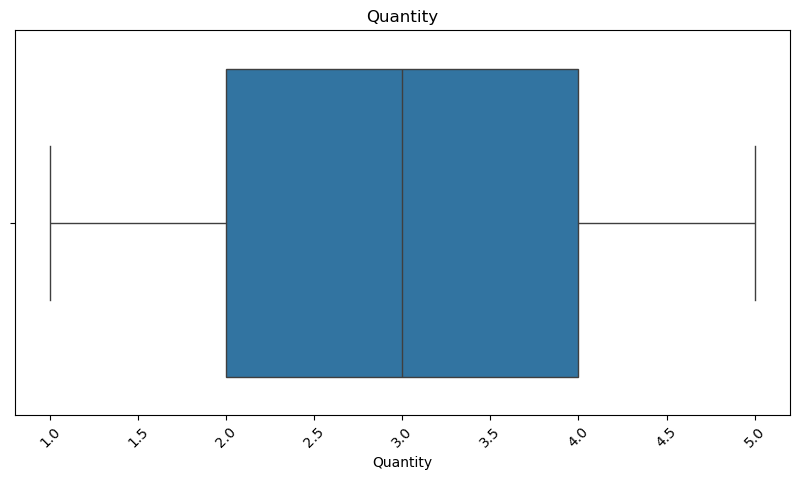

In [30]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Quantity', data=df)
plt.title('Quantity')
plt.xlabel('Quantity')
plt.xticks(rotation=45)

plt.show()

In [31]:
data = df['Delivery_Status'].value_counts()
data

Delivery_Status
Delivered    4790
Pending      4088
Returned     4000
Name: count, dtype: int64

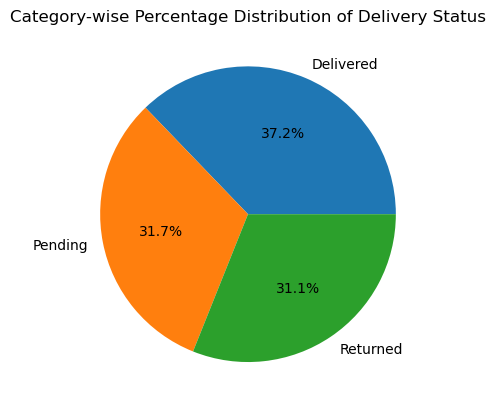

In [32]:
data.plot(
    kind='pie',
    autopct='%1.1f%%',
)
plt.ylabel('')   
plt.title('Category-wise Percentage Distribution of Delivery Status')
plt.show()

# Bivariate Analysis

In [33]:
category_sales = df.groupby('Product_Category')['Total_Sales_INR'].sum().sort_values(ascending=False)
category_sales


Product_Category
Beauty            1.867250e+08
Electronics       1.863101e+08
Books             1.840030e+08
Clothing          1.816763e+08
Home & Kitchen    1.772946e+08
Unkown            4.620549e+07
Name: Total_Sales_INR, dtype: float64

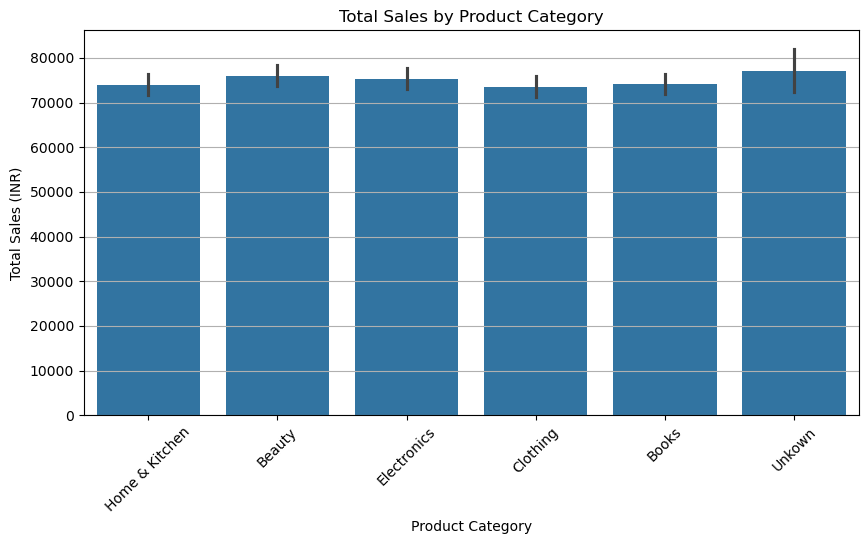

In [34]:
plt.figure(figsize=(10,5))
sns.barplot(x='Product_Category', y='Total_Sales_INR', data=df)
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales (INR)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

In [35]:
df.groupby('Customer_ID')['Order_ID'].count().describe()


count    6819.000000
mean        1.888547
std         1.027011
min         1.000000
25%         1.000000
50%         2.000000
75%         2.000000
max         8.000000
Name: Order_ID, dtype: float64

In [36]:
monthly_sales = df.groupby(['Order_Year','Order_Month'])['Total_Sales_INR'].sum()
monthly_sales

Order_Year  Order_Month
2025        1              79045648.63
            2              73682241.57
            3              78656326.40
            4              78089057.19
            5              81599602.26
            6              77714210.09
            7              80964767.90
            8              84192919.97
            9              78792258.77
            10             81833940.12
            11             81893220.73
            12             85750305.69
Name: Total_Sales_INR, dtype: float64

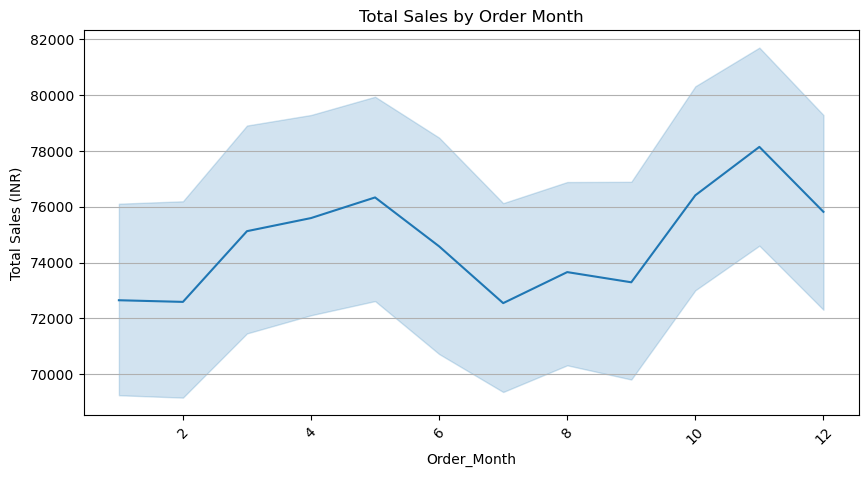

In [37]:
plt.figure(figsize=(10,5))
sns.lineplot(x='Order_Month', y='Total_Sales_INR', data=df)
plt.title('Total Sales by Order Month')
plt.xlabel('Order_Month')
plt.ylabel('Total Sales (INR)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

In [38]:
data = df.groupby('Product_Category')['Review_Rating'].mean().sort_values(ascending=False)
data

Product_Category
Electronics       3.091828
Unkown            3.070000
Beauty            3.055352
Home & Kitchen    3.055092
Books             3.028180
Clothing          3.005670
Name: Review_Rating, dtype: float64

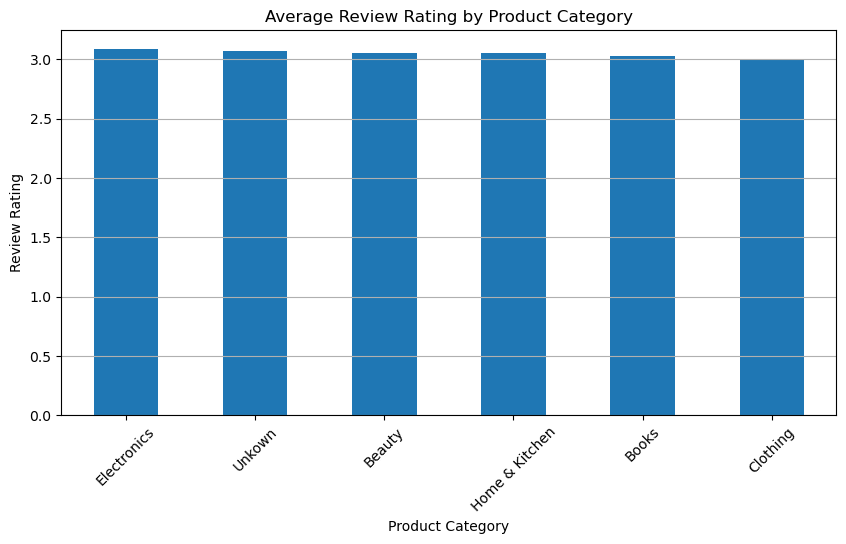

In [39]:
plt.figure(figsize=(10,5))
data.plot(kind='bar')
plt.title('Average Review Rating by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Review Rating')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

# Multivariate Analysis

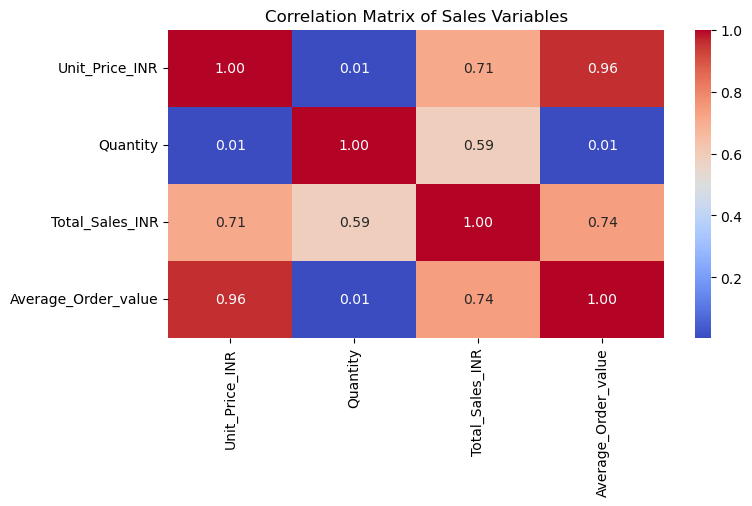

In [40]:
plt.figure(figsize=(8,4))

sns.heatmap(
    df[['Unit_Price_INR','Quantity','Total_Sales_INR','Average_Order_value']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Sales Variables')
plt.show()
